In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# set a clean visual style for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

# load the data, encoding handles special characters
df = pd.read_csv('SampleSuperstore.csv', encoding='latin-1')

# show the first 5 rows to see what I have
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [7]:
# how many rows and columns
print('Shape:', df.shape)

# what type of data is each column?
print('\nData types:')
print(df.dtypes)

# are there missing values?
print('\nMissing values per column:')
print(df.isnull().sum())

# summary on the number data type columns
df.describe()

Shape: (9994, 13)

Data types:
Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing values per column:
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [32]:
# create a profit margin %
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

# create a row number
df['Row Number'] = df.index + 1

# track added column
print('Columns added successfully. New shape:', df.shape)
df[['Sales','Profit','Profit Margin %','Row Number']].head()

Columns added successfully. New shape: (9994, 16)


,Sales,Profit,Profit Margin %,Row Number
0,261.9600,41.9136,16.00,1
1,731.9400,219.5820,30.00,2
2,14.6200,6.8714,47.00,3
3,957.5775,-383.0310,-40.00,4
4,22.3680,2.5164,11.25,5


Business Question #1: Where should the company focus its sales effort? Are there any product lines losing money?

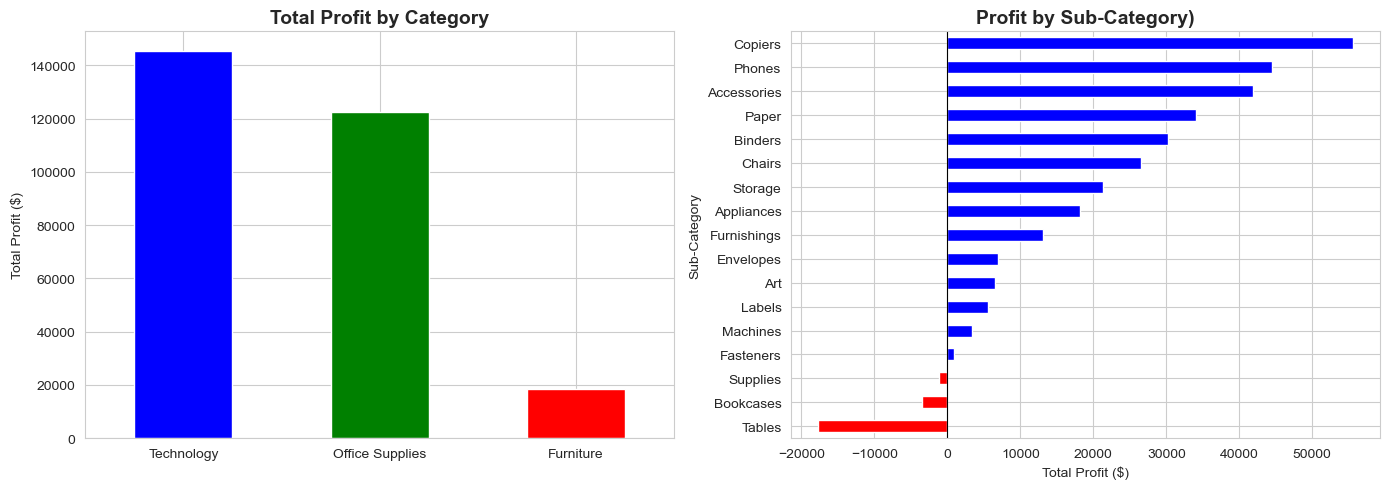


Profit by Category:
Category
Technology         145454.95
Office Supplies    122490.80
Furniture           18451.27
Name: Profit, dtype: float64

Loss-making sub-categories:
Sub-Category
Tables      -17725.48
Bookcases    -3472.56
Supplies     -1189.10
Name: Profit, dtype: float64


In [33]:
# group by category and sum profit
cat_profit = df.groupby('Category')['Profit'].sum().round(2).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# left chart is profit by category
cat_profit.plot(kind='bar', ax=axes[0],
                color=['blue', 'green', 'red'],
                edgecolor='white')
axes[0].set_title('Total Profit by Category', fontsize=14,
fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total Profit ($)')
axes[0].tick_params(axis='x', rotation=0)

# right chart is profit by sub category and highlighted red if negative
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'blue' for x in sub_profit]
sub_profit.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Profit by Sub-Category)',
                  fontsize=14, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Total Profit ($)')


plt.tight_layout()
plt.savefig('chart1_category_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nProfit by Category:')
print(cat_profit)
print('\nLoss-making sub-categories:')
print(df.groupby('Sub-Category')['Profit'].sum().round(2).sort_values().head(3))


Finding #1: Technology drives profit
Finding #2: Tables sub-category is loss-making and the recommendation is to review the discount policy
and pricing as an immediate priority

Business Question #2: Is discounting hurting profit?

               Avg_Margin  Order_Count
Discount Band                         
No discount         34.02         4798
1-10%               15.58           94
11-20%              17.48         3709
21-30%             -11.55          227
31-50%             -29.61          310
51%+              -113.88          856


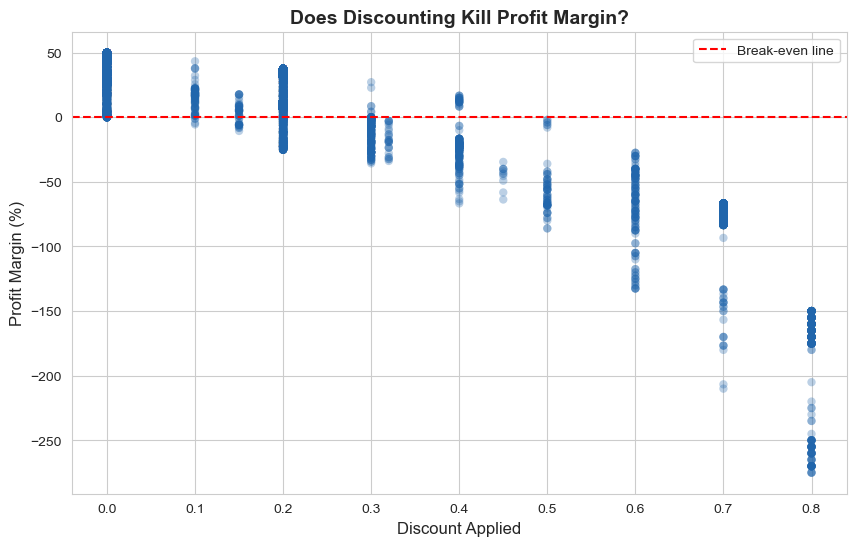

In [35]:
# group into discount bands
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1.0],
    labels=['No discount', '1-10%', '11-20%', '21-30%', '31-50%', '51%+']
)

# average profit margin per discount
discount_analysis = df.groupby('Discount Band').agg(
    Avg_Margin = ('Profit Margin %', 'mean'),
    Order_Count = ('Row Number', 'count')
).round(2)
print(discount_analysis)

# scatter plot with every order as a dot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['Discount'], df['Profit Margin %'],
           alpha=0.3, color='#2166ac', edgecolor='none')
ax.axhline(0, color ='red', linewidth=1.5,
           linestyle='--', label='Break-even line')
ax.set_xlabel('Discount Applied', fontsize=12)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
ax.set_title('Does Discounting Kill Profit Margin?',
            fontsize=14, fontweight='bold')
ax.legend()
plt.savefig('chart2_discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# export the clean dataset for Tableau
df.to_csv('superstore_clean.csv', index=False)
print('File exported: superstore_clean.csv')
print('Rows:', len(df))
print('Columns:', len(df.columns))

File exported: superstore_clean.csv
Rows: 9994
Columns: 16
